<h1> this is the first part of the assignment </h1>

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Transforms ────────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Dataloaders ───────────────────────────────────────────────────────────────
cifar10_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
cifar10_test  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(cifar10_test,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# ── Model ─────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 100),
            nn.BatchNorm1d(100),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(100, 300),
            nn.BatchNorm1d(300),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(300, 100),
            nn.BatchNorm1d(100),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(100, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='leaky_relu')
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        return self.network(x)

# ── Setup ─────────────────────────────────────────────────────────────────────
model     = MLP(input_dim=3*64*64, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)
NUM_EPOCHS = 4

# ── Training Loop ─────────────────────────────────────────────────────────────
for epoch in range(1, NUM_EPOCHS + 1):

    # Train
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(train_loader, desc=f"Epoch [{epoch:02d}/{NUM_EPOCHS}]", unit="batch", ncols=100)
    for images, labels in bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds    = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        total_loss += loss.item() * labels.size(0)

        bar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")

    train_loss, train_acc = total_loss / total, correct / total

    # Validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits       = model(images)
            val_loss    += criterion(logits, labels).item() * labels.size(0)
            val_correct += (logits.argmax(dim=1) == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / val_total
    val_acc  = val_correct / val_total

    # Update bar with final metrics and keep it
    bar.set_postfix(
        train_loss=f"{train_loss:.4f}", train_acc=f"{train_acc:.4f}",
        val_loss=f"{val_loss:.4f}",     val_acc=f"{val_acc:.4f}"
    )
    bar.close()

Using device: cuda


Epoch [04/4]: 100%|███████████████████| 782/782 [00:23<00:00, 33.06batch/s, acc=0.5104, loss=1.3602]


<h2> the accuracy and loss are not too good because the 1d assumption about image which is wrong for this case so in the next part I will use the CNN Network and see the difference

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Transforms ────────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Dataloaders ───────────────────────────────────────────────────────────────
cifar10_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
cifar10_test  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(cifar10_test,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# ── Model ─────────────────────────────────────────────────────────────────────
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 2 * 2, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# ── Setup ─────────────────────────────────────────────────────────────────────
model     = CNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 10

# ── Training Loop ─────────────────────────────────────────────────────────────
for epoch in range(1, NUM_EPOCHS + 1):

    # Train
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(train_loader, desc=f"Epoch [{epoch:02d}/{NUM_EPOCHS}]", unit="batch", ncols=100)
    for images, labels in bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds    = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        total_loss += loss.item() * labels.size(0)

        bar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")

    train_loss, train_acc = total_loss / total, correct / total

    # Validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits       = model(images)
            val_loss    += criterion(logits, labels).item() * labels.size(0)
            val_correct += (logits.argmax(dim=1) == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / val_total
    val_acc  = val_correct / val_total

    print(f"\nEpoch [{epoch:02d}/{NUM_EPOCHS}] => "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

Using device: cuda


Epoch [01/10]: 100%|██████████████████| 782/782 [00:25<00:00, 30.68batch/s, acc=0.6019, loss=1.1146]



Epoch [01/10] => Train Loss: 1.1146 | Train Acc: 0.6019 | Val Loss: 0.9108 | Val Acc: 0.6813



Epoch [02/10]: 100%|██████████████████| 782/782 [00:28<00:00, 27.28batch/s, acc=0.7439, loss=0.7310]



Epoch [02/10] => Train Loss: 0.7310 | Train Acc: 0.7439 | Val Loss: 0.7622 | Val Acc: 0.7363



...


Epoch [08/10] => Train Loss: 0.1488 | Train Acc: 0.9465 | Val Loss: 0.7984 | Val Acc: 0.7955



Epoch [09/10]: 100%|██████████████████| 782/782 [00:25<00:00, 30.30batch/s, acc=0.9592, loss=0.1144]



Epoch [09/10] => Train Loss: 0.1144 | Train Acc: 0.9592 | Val Loss: 0.8544 | Val Acc: 0.7954



Epoch [10/10]: 100%|██████████████████| 782/782 [00:25<00:00, 30.28batch/s, acc=0.9634, loss=0.1035]



Epoch [10/10] => Train Loss: 0.1035 | Train Acc: 0.9634 | Val Loss: 0.8634 | Val Acc: 0.7950



<h1> The CNN model achieves higher accuracy and performance over the Simple MLP but there is an outstanding overfitting so we must add some regularization to the model</h1>

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Transforms ────────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Dataloaders ───────────────────────────────────────────────────────────────
cifar10_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
cifar10_test  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(cifar10_test,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# ── Model ─────────────────────────────────────────────────────────────────────
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.01), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
          nn.Dropout(0.5),
          nn.Linear(256 * 2 * 2, 512),
          nn.BatchNorm1d(512),
          nn.GELU(),
          nn.Linear(512, num_classes),
          )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# ── Setup ─────────────────────────────────────────────────────────────────────
model     = CNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 10

# ── Training Loop ─────────────────────────────────────────────────────────────
for epoch in range(1, NUM_EPOCHS + 1):

    # Train
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(train_loader, desc=f"Epoch [{epoch:02d}/{NUM_EPOCHS}]", unit="batch", ncols=100)
    for images, labels in bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds    = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        total_loss += loss.item() * labels.size(0)

        bar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")

    train_loss, train_acc = total_loss / total, correct / total

    # Validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits       = model(images)
            val_loss    += criterion(logits, labels).item() * labels.size(0)
            val_correct += (logits.argmax(dim=1) == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / val_total
    val_acc  = val_correct / val_total

    print(f"\nEpoch [{epoch:02d}/{NUM_EPOCHS}] => "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

Using device: cuda


Epoch [01/10]: 100%|██████████████████| 782/782 [00:25<00:00, 30.74batch/s, acc=0.5549, loss=1.2265]



Epoch [01/10] => Train Loss: 1.2265 | Train Acc: 0.5549 | Val Loss: 0.9468 | Val Acc: 0.6618



Epoch [02/10]: 100%|██████████████████| 782/782 [00:25<00:00, 30.10batch/s, acc=0.6970, loss=0.8590]



Epoch [02/10] => Train Loss: 0.8590 | Train Acc: 0.6970 | Val Loss: 0.8310 | Val Acc: 0.7089



...


Epoch [08/10] => Train Loss: 0.3888 | Train Acc: 0.8625 | Val Loss: 0.5668 | Val Acc: 0.8077



Epoch [09/10]: 100%|██████████████████| 782/782 [00:25<00:00, 30.34batch/s, acc=0.8751, loss=0.3490]



Epoch [09/10] => Train Loss: 0.3490 | Train Acc: 0.8751 | Val Loss: 0.5919 | Val Acc: 0.8016



Epoch [10/10]: 100%|██████████████████| 782/782 [00:25<00:00, 30.20batch/s, acc=0.8885, loss=0.3129]



Epoch [10/10] => Train Loss: 0.3129 | Train Acc: 0.8885 | Val Loss: 0.5696 | Val Acc: 0.8125



<h2> adding drop out improves the val accuracy little bit from 79 to 81.25 </h2>

<h2> Moving to the next part of assignment by finetuning pretrained model I will use resnet 32 <h2>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

cifar10_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
cifar10_test  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(cifar10_test,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

NUM_EPOCHS = 5

Using device: cuda


In [2]:
def train_and_evaluate(model, train_loader, val_loader, optimizer, num_epochs=5):
    criterion = nn.CrossEntropyLoss()
    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        bar = tqdm(train_loader, desc=f"Epoch [{epoch:02d}/{num_epochs}]", unit="batch", ncols=100)
        for images, labels in bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item() * labels.size(0)
            bar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")

        train_loss, train_acc = total_loss / total, correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                val_loss += criterion(logits, labels).item() * labels.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss, val_acc = val_loss / val_total, val_correct / val_total
        print(f"\nEpoch [{epoch:02d}/{num_epochs}] => "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

In [3]:
pretresnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

In [4]:
device = 'cuda'

In [5]:
# Scenario A: Freeze everything, train only FC
model_a = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model_a.parameters():
    param.requires_grad = False

model_a.fc = nn.Linear(model_a.fc.in_features,10 )
model_a = model_a.to(device)

optimizer_a = optim.Adam(model_a.fc.parameters(), lr=8e-3)
print("=== Scenario A: Only FC Layer ===")
train_and_evaluate(model_a, train_loader, val_loader, optimizer_a, 3)

=== Scenario A: Only FC Layer ===


Epoch [01/3]: 100%|███████████████████| 782/782 [01:37<00:00,  8.00batch/s, acc=0.7334, loss=0.8065]



Epoch [01/3] => Train Loss: 0.8065 | Train Acc: 0.7334 | Val Loss: 0.7422 | Val Acc: 0.7699



Epoch [02/3]: 100%|███████████████████| 782/782 [01:35<00:00,  8.17batch/s, acc=0.7622, loss=0.7567]



Epoch [02/3] => Train Loss: 0.7567 | Train Acc: 0.7622 | Val Loss: 0.7990 | Val Acc: 0.7550



Epoch [03/3]: 100%|███████████████████| 782/782 [01:39<00:00,  7.89batch/s, acc=0.7674, loss=0.7469]



Epoch [03/3] => Train Loss: 0.7469 | Train Acc: 0.7674 | Val Loss: 0.9091 | Val Acc: 0.7373



In [6]:
# Unfreeze layer4
for param in model_a.layer4.parameters():
    param.requires_grad = True

optimizer_b = optim.Adam(filter(lambda p: p.requires_grad, model_a.parameters()), lr=1e-3)
print("=== Scenario B: Finetune Layer4 + FC ===")
train_and_evaluate(model_a, train_loader, val_loader, optimizer_b, 3)

=== Scenario B: Finetune Layer4 + FC ===


Epoch [01/3]: 100%|███████████████████| 782/782 [01:37<00:00,  8.00batch/s, acc=0.8473, loss=0.4851]



Epoch [01/3] => Train Loss: 0.4851 | Train Acc: 0.8473 | Val Loss: 0.3723 | Val Acc: 0.8761



Epoch [02/3]: 100%|███████████████████| 782/782 [01:37<00:00,  8.02batch/s, acc=0.9207, loss=0.2262]



Epoch [02/3] => Train Loss: 0.2262 | Train Acc: 0.9207 | Val Loss: 0.3059 | Val Acc: 0.8967



Epoch [03/3]: 100%|███████████████████| 782/782 [01:37<00:00,  8.03batch/s, acc=0.9521, loss=0.1411]



Epoch [03/3] => Train Loss: 0.1411 | Train Acc: 0.9521 | Val Loss: 0.3267 | Val Acc: 0.9032



In [7]:
# Unfreeze all
for param in model_a.parameters():
    param.requires_grad = True

# Replace FC with Dropout + Linear
model_a.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512, 10)
).to(device)

optimizer_c = optim.Adam(model_a.parameters(), lr=3e-4)
print("=== Scenario C: Finetune Whole Model with Dropout ===")
train_and_evaluate(model_a, train_loader, val_loader, optimizer_c, 2)

=== Scenario C: Finetune Whole Model with Dropout ===


Epoch [01/2]: 100%|███████████████████| 782/782 [02:29<00:00,  5.24batch/s, acc=0.9099, loss=0.2726]



Epoch [01/2] => Train Loss: 0.2726 | Train Acc: 0.9099 | Val Loss: 0.2454 | Val Acc: 0.9182



Epoch [02/2]: 100%|███████████████████| 782/782 [02:31<00:00,  5.16batch/s, acc=0.9633, loss=0.1128]



Epoch [02/2] => Train Loss: 0.1128 | Train Acc: 0.9633 | Val Loss: 0.2556 | Val Acc: 0.9149



the transfer learning outperforms the custom cnn and mlp by achieving 92.03 accuracy on val set and 99.3 on training we can improve it more by using drop out but 92.03 is good enough right now



1.   first run finetune the last layer to be representative to the classification task and freeze other layer and using higher learning rate to improve this layer weight quickly
2.   second strategy to freeze all layer except fc layer 4 feature extraction cell this step will improve feature extraction for this task
3. third cell is about training the full network with smaller learning rate to improve the full network in stable way by using this strategy we achieve good accuracy in val we can do better by using drop out and train it for long time



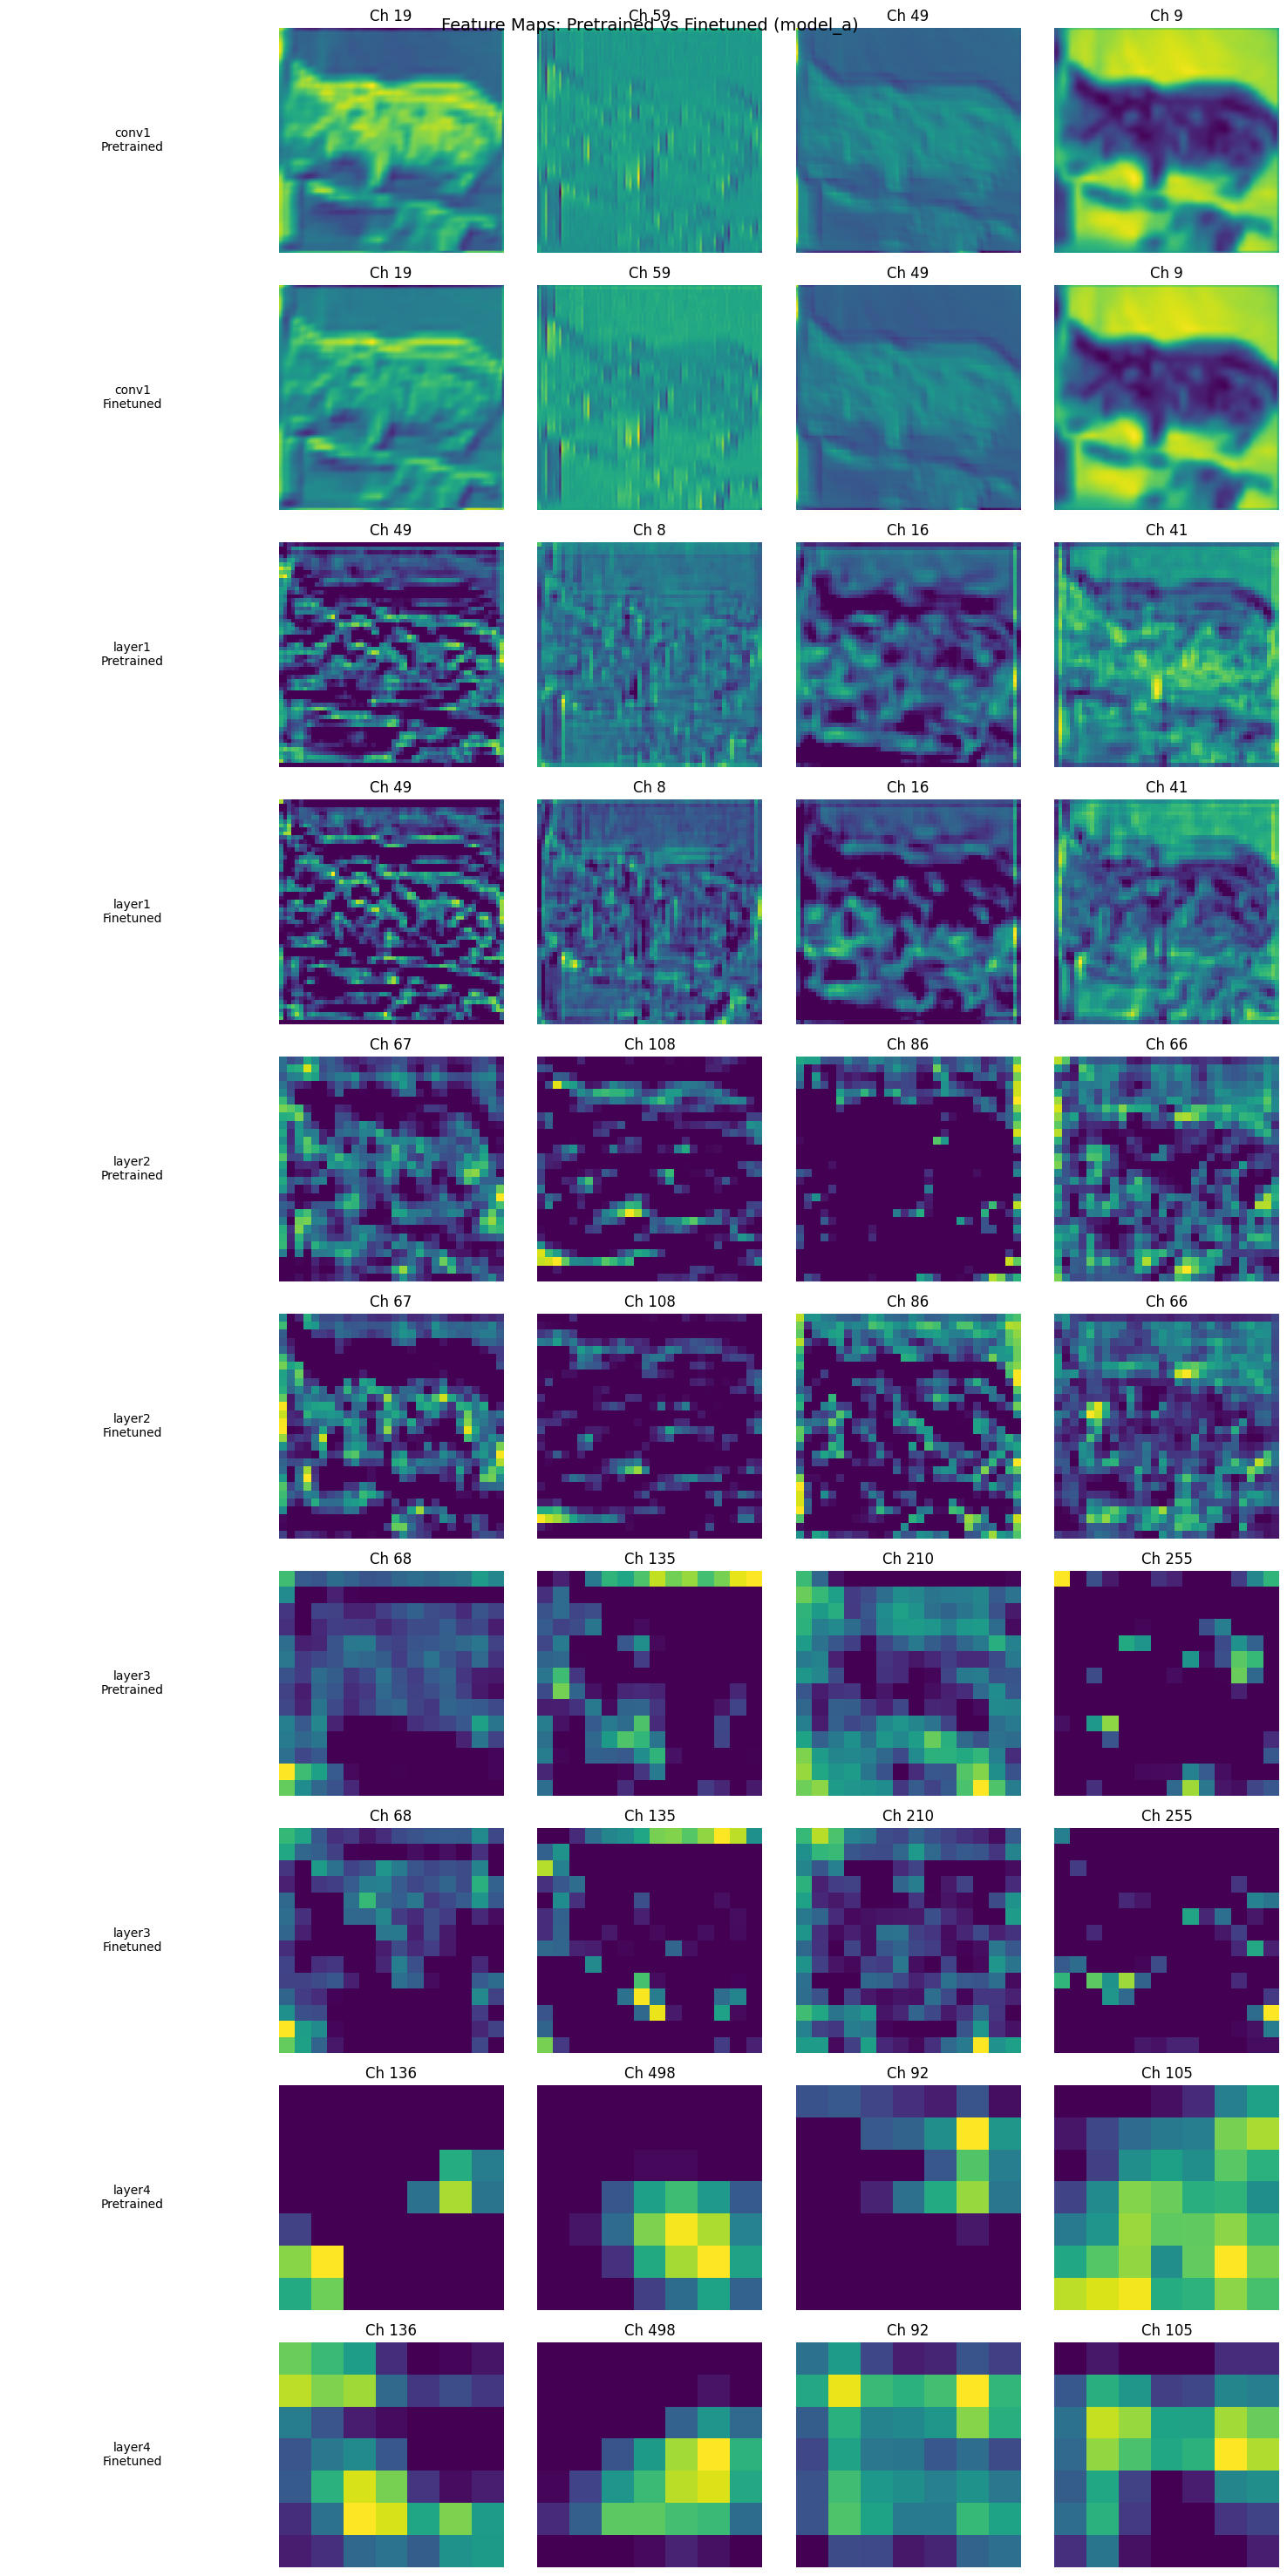

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Load fresh pretrained model (not finetuned)
pretresnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
pretresnet_model.fc = nn.Linear(pretresnet_model.fc.in_features, 10)
pretresnet_model = pretresnet_model.to(device)
pretresnet_model.eval()
model_a.eval()

# Pick a random test image
img, label = cifar10_test[np.random.randint(len(cifar10_test))]
input_tensor = img.unsqueeze(0).to(device)

# Layers to hook
layer_names = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4']

def get_feature_maps(model, input_tensor, layer_names):
    feature_maps = {}
    hooks = []

    def hook_fn(name):
        def hook(module, input, output):
            feature_maps[name] = output.detach().cpu()
        return hook

    for name in layer_names:
        layer = getattr(model, name)
        hooks.append(layer.register_forward_hook(hook_fn(name)))

    with torch.no_grad():
        model(input_tensor)

    for h in hooks:
        h.remove()

    return feature_maps

# Get feature maps from both models
fmaps_pre  = get_feature_maps(pretresnet_model, input_tensor, layer_names)
fmaps_fine = get_feature_maps(model_a, input_tensor, layer_names)

# Plot
num_channels = 4  # show 4 random channels per layer

fig, axes = plt.subplots(len(layer_names) * 2, num_channels + 1,
                          figsize=(3 * (num_channels + 1), 3 * len(layer_names) * 2))

for i, name in enumerate(layer_names):
    row_pre  = i * 2
    row_fine = i * 2 + 1

    fm_pre  = fmaps_pre[name][0]
    fm_fine = fmaps_fine[name][0]

    indices = np.random.choice(fm_pre.shape[0], num_channels, replace=False)

    # Label column
    axes[row_pre, 0].text(0.5, 0.5, f"{name}\nPretrained", fontsize=10,
                           ha='center', va='center', transform=axes[row_pre, 0].transAxes)
    axes[row_pre, 0].axis("off")
    axes[row_fine, 0].text(0.5, 0.5, f"{name}\nFinetuned", fontsize=10,
                            ha='center', va='center', transform=axes[row_fine, 0].transAxes)
    axes[row_fine, 0].axis("off")

    for j, idx in enumerate(indices):
        axes[row_pre, j + 1].imshow(fm_pre[idx], cmap='viridis')
        axes[row_pre, j + 1].set_title(f"Ch {idx}")
        axes[row_pre, j + 1].axis("off")

        axes[row_fine, j + 1].imshow(fm_fine[idx], cmap='viridis')
        axes[row_fine, j + 1].set_title(f"Ch {idx}")
        axes[row_fine, j + 1].axis("off")

plt.suptitle("Feature Maps: Pretrained vs Finetuned (model_a)", fontsize=14)
plt.tight_layout()
plt.show()

# Early layers (conv1, layer1) detect low-level features like edges and textures
#  for a cat image, layer1 highlights fur edges and contours
# Deeper layers (layer3, layer4) capture high level semantic features
# e.g. layer4 activations represent abstract object level understanding

we see sum channel that illustrates the ears , eyes and the first layers illustrate the edges